<a href="https://colab.research.google.com/github/NzubechiOkere/cv/blob/main/Smart_Meter_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
print("pandas is working!")

pandas is working!


In [ ]:
import sys, pandas as pd, numpy as np
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Ready to go!")


Python: 3.12.12
pandas: 2.2.2
numpy: 2.0.2
Ready to go!


In [ ]:
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


In [ ]:
from google.colab import files
uploaded = files.upload()  # choose your file in the popup
filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

Saving phase 2 data.txt to phase 2 data.txt
Uploaded: phase 2 data.txt


In [ ]:
import pandas as pd

df = pd.read_csv(
    filename,
    sep=';',                 # important: semicolon-separated
    na_values=['?'],         # turn '?' into real missing values (NaN)
    low_memory=False
)
print(df.shape)
df.head()


(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                errors='coerce', dayfirst=True)

# Drop the old separate columns (optional)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Sort so times are in order
df = df.sort_values('Datetime').reset_index(drop=True)

df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [ ]:
print("Duplicates:", df['Datetime'].duplicated().sum())
print("Missing Datetime values:", df['Datetime'].isna().sum())


Duplicates: 0
Missing Datetime values: 0


In [ ]:
# Count missing values per column
df.isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979
Datetime,0


In [ ]:
# Sort by time just to be safe
df = df.sort_values('Datetime')

# show how many missing in each column
print(df.isna().sum())

# interpolate all numeric columns linearly
df = df.interpolate(method='linear')

# check again
print("\nAfter interpolation:")
print(df.isna().sum())


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

After interpolation:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64


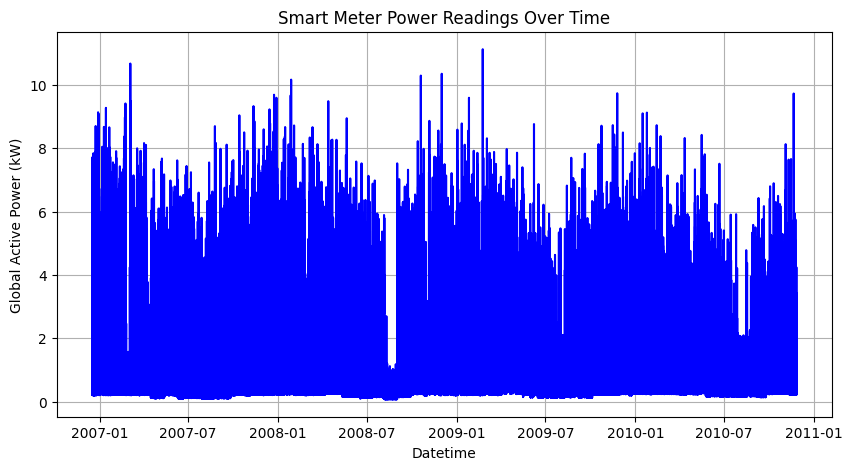

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Datetime'], df['Global_active_power'], color='blue')
plt.title('Smart Meter Power Readings Over Time')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.show()


In [ ]:
# Step 6A — detect which columns are numeric
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns:", list(numeric_cols))

# Step 6B — apply IQR method to all numeric columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("\nOutlier capping complete.")


Numeric columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Outlier capping complete.


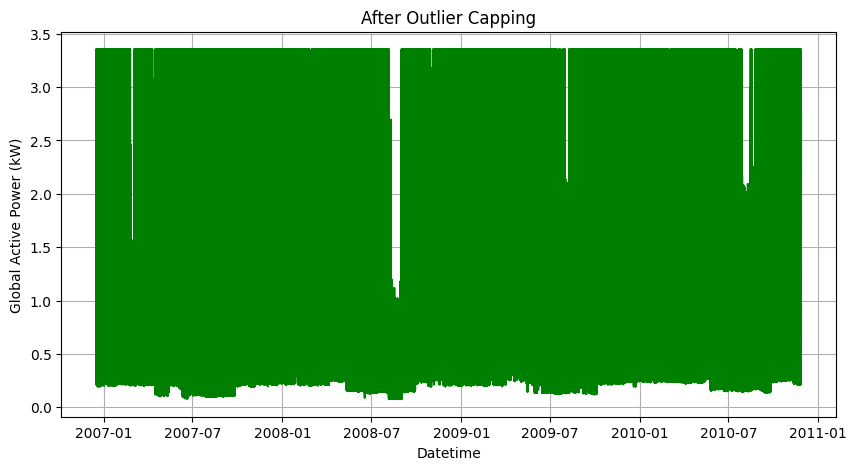

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Datetime'], df['Global_active_power'], color='green')
plt.title('After Outlier Capping')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.show()


In [ ]:
# Step 7A — save the cleaned dataset
df.to_csv('cleaned_smart_meter.csv', index=False)

# Step 7B — download it to your computer
from google.colab import files
files.download('cleaned_smart_meter.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Step 10A — copy the cleaned dataset
df_scaled = df.copy()

# Step 10B — list of numeric columns to scale
cols_to_scale = ['Global_active_power', 'Global_reactive_power',
                 'Voltage', 'Global_intensity',
                 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [13]:
scaler = MinMaxScaler()

# Fit the scaler to your selected columns and transform them
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

# Check a few rows to confirm
df_scaled.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,1.0,1.0,0.107603,1.0,0.0,0.4,0.548387,2006-12-16 17:24:00
1,1.0,1.0,0.029639,1.0,0.0,0.4,0.516129,2006-12-16 17:25:00
2,1.0,1.0,0.007732,1.0,0.0,0.8,0.548387,2006-12-16 17:26:00
3,1.0,1.0,0.036727,1.0,0.0,0.4,0.548387,2006-12-16 17:27:00
4,1.0,1.0,0.161727,1.0,0.0,0.4,0.548387,2006-12-16 17:28:00


In [16]:
df_scaled.to_csv('normalized_smart_meter.csv', index=False)

from google.colab import files
files.download('normalized_smart_meter.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>